In [3]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split

In [12]:
filename = "/content/out_features.jsonl"


data = []
with open(filename, "r", encoding="utf-8") as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue

df = pd.DataFrame(data)
df

,id,label,source,input,measurements,features
0,6911d21446483f1ce32438ed,phishing,phishing_db.website_content,{'url': 'https://app46657.swiftway.in/webserve...,"{'url_length': 63, 'final_url_length': 63, 'fi...","[{'id': 'meta.robots_noindex_nofollow', 'direc..."
1,6911d21546483f1ce32438ee,phishing,phishing_db.website_content,{'url': 'https://quitshadow.com/mko/index.php'...,"{'url_length': 36, 'final_url_length': 36, 'fi...","[{'id': 'credential.password_input_present', '..."
2,6911d21946483f1ce32438ef,phishing,phishing_db.website_content,"{'url': 'http://www.twiz.me/u7r88b6k/', 'final...","{'url_length': 28, 'final_url_length': 36, 'fi...","[{'id': 'redirect.multi_hop', 'direction': 'su..."
3,6911d21d46483f1ce32438f1,phishing,phishing_db.website_content,{'url': 'https://streijl.eu/images/media/inc/n...,"{'url_length': 56, 'final_url_length': 56, 'fi...","[{'id': 'credential.password_input_present', '..."
4,6911d23712b7a8e079909292,phishing,phishing_db.website_content,{'url': 'https://bafkreiaww32bm77n2jnyv3w6v4nc...,"{'url_length': 83, 'final_url_length': 83, 'fi...","[{'id': 'url.deep_subdomain', 'direction': 'su..."
...,...,...,...,...,...,...
79995,69d4bb9e0c28a438c1198359,benign,tranco.websites,"{'url': 'https://neu.aggb-katalog.de/vufind/',...","{'url_length': 35, 'final_url_length': 35, 'fi...","[{'id': 'contact.identity_domain_mismatch', 'd..."
79996,69d4bb9e0c28a438c119835a,benign,tranco.websites,{'url': 'https://neu.aggb-katalog.de/vufind/My...,"{'url_length': 61, 'final_url_length': 61, 'fi...","[{'id': 'credential.password_input_present', '..."
79997,69d4bb9e0c28a438c119835b,benign,tranco.websites,{'url': 'https://neu.aggb-katalog.de/vufind/My...,"{'url_length': 55, 'final_url_length': 55, 'fi...","[{'id': 'credential.password_input_present', '..."
79998,69d4bb9e0c28a438c119835c,benign,tranco.websites,{'url': 'https://neu.aggb-katalog.de/vufind/He...,"{'url_length': 70, 'final_url_length': 70, 'fi...",[{'id': 'navigation.functional_internal_links'...


In [7]:
import json

with open(filename, "r") as f:
    first_line = f.readline()
    first_entry = json.loads(first_line)

print("Keys in each entry:")
print(list(first_entry.keys()))
print()
print("Full first entry:")
print(json.dumps(first_entry, indent=2, ensure_ascii=False))

Keys in each entry:
['id', 'label', 'source', 'input', 'measurements', 'features']

Full first entry:
{
  "id": "6911d21446483f1ce32438ed",
  "label": "phishing",
  "source": "phishing_db.website_content",
  "input": {
    "url": "https://app46657.swiftway.in/webserver103/?8788898=3mail@a.b.c0",
    "final_url": "https://app46657.swiftway.in/webserver103/?8788898=3mail@a.b.c0",
    "redirects": [],
    "title": "Outlook Web App",
    "meta": [
      {
        "http_equiv": "Content-Type",
        "content": "text/html; charset=UTF-8"
      },
      {
        "name": "Robots",
        "content": "NOINDEX, NOFOLLOW"
      }
    ],
    "visible_text": "Webmail Web mail access application Security( show explanation ) This is a public or shared computer This is a private computer Use the light version of Webmail App Email address: Password: Connected to Webmail Exchange Â© 2024 Webmail. All rights reserved.",
    "forms": {
      "total_observed": 1,
      "items": [
        {
          "me

In [8]:
with open(filename, "r") as f:
    first_entry = json.loads(f.readline())

# Print each field nicely
for key, value in first_entry.items():
    print(f"--- {key} ---")
    # Truncate long values for readability
    value_str = str(value)
    if len(value_str) > 500:
        print(value_str[:500] + "... [truncated]")
    else:
        print(value_str)
    print()

--- id ---
6911d21446483f1ce32438ed

--- label ---
phishing

--- source ---
phishing_db.website_content

--- input ---
{'url': 'https://app46657.swiftway.in/webserver103/?8788898=3mail@a.b.c0', 'final_url': 'https://app46657.swiftway.in/webserver103/?8788898=3mail@a.b.c0', 'redirects': [], 'title': 'Outlook Web App', 'meta': [{'http_equiv': 'Content-Type', 'content': 'text/html; charset=UTF-8'}, {'name': 'Robots', 'content': 'NOINDEX, NOFOLLOW'}], 'visible_text': 'Webmail Web mail access application Security( show explanation ) This is a public or shared computer This is a private computer Use the light version ... [truncated]

--- measurements ---
{'url_length': 63, 'final_url_length': 63, 'final_hostname': 'app46657.swiftway.in', 'hostname_label_count': 3, 'redirect_count': 0, 'form_count': 1, 'credential_form_count': 1, 'password_input_count': 1, 'hidden_input_count': 2, 'form_action_relationship_counts': {}, 'anchor_count': 1, 'external_anchor_count': 0, 'external_anchor_ratio': 0.

In [14]:
print("Label counts:")
print(df['label'].value_counts())
print()
print("Percentages:")
print(df['label'].value_counts(normalize=True) * 100)

Label counts:
label
phishing    40000
benign      40000
Name: count, dtype: int64

Percentages:
label
phishing    50.0
benign      50.0
Name: proportion, dtype: float64


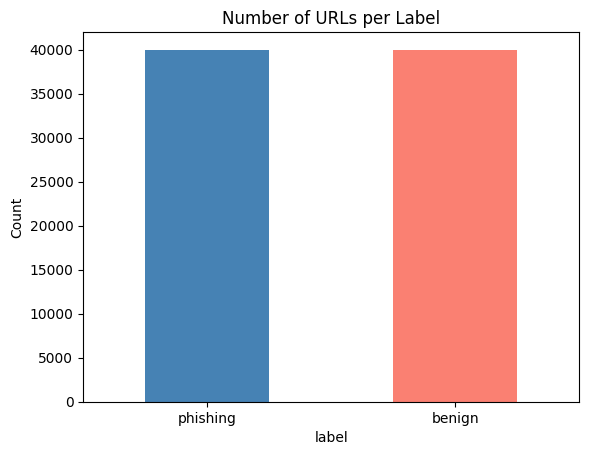

In [15]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Number of URLs per Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [16]:
df['num_features'] = df['features'].apply(len)

print("Feature count statistics by label:")
print(df.groupby('label')['num_features'].describe())

Feature count statistics by label:
            count     mean       std  min  25%  50%  75%   max
label                                                         
benign    40000.0  4.84795  2.723099  0.0  3.0  4.0  7.0  14.0
phishing  40000.0  4.68865  3.000639  0.0  2.0  5.0  7.0  14.0


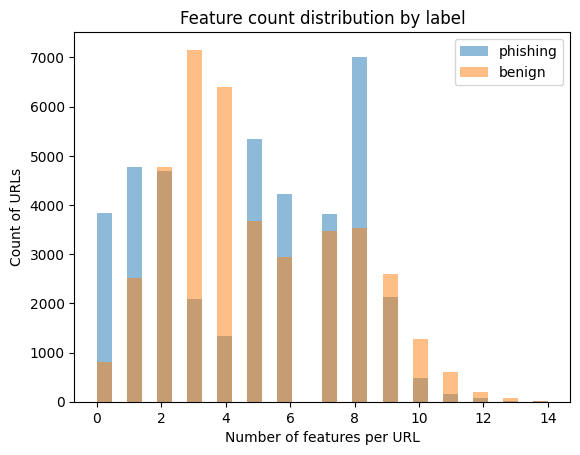

In [17]:
import matplotlib.pyplot as plt

for label in df['label'].unique():
    subset = df[df['label'] == label]['num_features']
    plt.hist(subset, bins=30, alpha=0.5, label=label)

plt.xlabel('Number of features per URL')
plt.ylabel('Count of URLs')
plt.title('Feature count distribution by label')
plt.legend()
plt.show()

In [18]:
from collections import Counter

all_signals = []
for feats in df['features']:
    for f in feats:
        all_signals.append(f['id'])

signal_counts = Counter(all_signals)
print("Top 20 most common signals:")
for sig, count in signal_counts.most_common(20):
    print(f"{count:6d}  {sig}")

Top 20 most common signals:
 45457  link.null_or_void_anchors
 43987  navigation.functional_internal_links
 38051  support.contact_domain_match
 32940  credential.credential_terms_near_form
 27015  page.generic_login_without_brand_claim
 24056  iframe.hidden_iframe
 19597  credential.password_input_present
 19313  form.hidden_inputs
 18903  login.missing_recovery_or_help_flow
 18016  form.action_same_org_domain
 15215  form.empty_or_blank_action
 10699  form.blank_action_js_submission_suspected
  9524  contact.identity_domain_mismatch
  9151  link.brand_text_domain_mismatch
  7634  url.deep_subdomain
  6712  brand.title_domain_mismatch
  6144  meta.robots_noindex_nofollow
  4837  page.interstitial_without_credential_collection
  3530  redirect.multi_hop
  3213  url.long_url


In [19]:
from collections import Counter

def count_signals(subset):
    signals = []
    for feats in subset['features']:
        for f in feats:
            signals.append(f['id'])
    return Counter(signals)

phishing_signals = count_signals(df[df['label'] == 'phishing'])
benign_signals = count_signals(df[df['label'] == 'benign'])

print("Top 15 signals in PHISHING URLs:")
for sig, count in phishing_signals.most_common(15):
    print(f"{count:6d}  {sig}")

print()
print("Top 15 signals in BENIGN URLs:")
for sig, count in benign_signals.most_common(15):
    print(f"{count:6d}  {sig}")

Top 15 signals in PHISHING URLs:
 22392  link.null_or_void_anchors
 19862  credential.credential_terms_near_form
 17551  page.generic_login_without_brand_claim
 13684  login.missing_recovery_or_help_flow
 13628  support.contact_domain_match
 13562  credential.password_input_present
 10241  form.hidden_inputs
 10074  form.action_same_org_domain
  9898  form.empty_or_blank_action
  8196  navigation.functional_internal_links
  6155  brand.title_domain_mismatch
  6048  form.blank_action_js_submission_suspected
  5649  iframe.hidden_iframe
  4096  url.deep_subdomain
  3997  meta.robots_noindex_nofollow

Top 15 signals in BENIGN URLs:
 35791  navigation.functional_internal_links
 24423  support.contact_domain_match
 23065  link.null_or_void_anchors
 18407  iframe.hidden_iframe
 13078  credential.credential_terms_near_form
  9464  page.generic_login_without_brand_claim
  9072  form.hidden_inputs
  7942  form.action_same_org_domain
  7915  link.brand_text_domain_mismatch
  6035  credential.pas

In [20]:
import pandas as pd

# Build a table: for each signal, count how often it appears in each label
rows = []
all_signal_ids = set(phishing_signals.keys()) | set(benign_signals.keys())

n_phishing = (df['label'] == 'phishing').sum()
n_benign = (df['label'] == 'benign').sum()

for sig in all_signal_ids:
    p_count = phishing_signals.get(sig, 0)
    b_count = benign_signals.get(sig, 0)
    p_rate = p_count / n_phishing if n_phishing > 0 else 0
    b_rate = b_count / n_benign if n_benign > 0 else 0
    rows.append({
        'signal': sig,
        'phishing_count': p_count,
        'benign_count': b_count,
        'phishing_rate': round(p_rate, 3),
        'benign_rate': round(b_rate, 3),
        'diff (phish - benign)': round(p_rate - b_rate, 3)
    })

signal_df = pd.DataFrame(rows).sort_values('diff (phish - benign)', ascending=False)
print("Signals most indicative of PHISHING:")
print(signal_df.head(15).to_string(index=False))
print()
print("Signals most indicative of BENIGN:")
print(signal_df.tail(15).to_string(index=False))

Signals most indicative of PHISHING:
                                   signal  phishing_count  benign_count  phishing_rate  benign_rate  diff (phish - benign)
      login.missing_recovery_or_help_flow           13684          5219          0.342        0.130                  0.212
   page.generic_login_without_brand_claim           17551          9464          0.439        0.237                  0.202
        credential.password_input_present           13562          6035          0.339        0.151                  0.188
    credential.credential_terms_near_form           19862         13078          0.497        0.327                  0.170
              brand.title_domain_mismatch            6155           557          0.154        0.014                  0.140
               form.empty_or_blank_action            9898          5317          0.247        0.133                  0.115
              form.action_same_org_domain           10074          7942          0.252        0.199   

In [21]:
from collections import Counter

def count_severity(subset):
    sevs = []
    for feats in subset['features']:
        for f in feats:
            sevs.append(f.get('severity', 'unknown'))
    return Counter(sevs)

print("Severity counts in PHISHING:")
print(count_severity(df[df['label'] == 'phishing']))
print()
print("Severity counts in BENIGN:")
print(count_severity(df[df['label'] == 'benign']))

Severity counts in PHISHING:
Counter({'low': 92021, 'medium': 79427, 'high': 16098})

Severity counts in BENIGN:
Counter({'low': 122397, 'medium': 63185, 'high': 8336})


In [22]:
from collections import Counter

def count_direction(subset):
    dirs = []
    for feats in subset['features']:
        for f in feats:
            dirs.append(f.get('direction', 'unknown'))
    return Counter(dirs)

print("Direction counts in PHISHING:")
print(count_direction(df[df['label'] == 'phishing']))
print()
print("Direction counts in BENIGN:")
print(count_direction(df[df['label'] == 'benign']))

Direction counts in PHISHING:
Counter({'suspicious': 127055, 'benign': 32094, 'uncertain': 28175, 'neutral': 222})

Direction counts in BENIGN:
Counter({'suspicious': 106555, 'benign': 68781, 'uncertain': 18465, 'neutral': 117})
